# Installing the necessary packages

In [ ]:
!pip install playwright
!playwright install
!pip install praw
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Loading necessary libraries

In [138]:
import praw
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
import time

load_dotenv()

reddit = praw.Reddit(
    client_id = os.getenv('reddit_client_id'),
    client_secret = os.getenv('reddit_client_secret'),
    password = os.getenv('reddit_password'),
    username = os.getenv('reddit_username'),
    user_agent= os.getenv('reddit_user_agent')
)

In [86]:
def fetch_posts(subreddit_name, query, limit=None, delay=0.5, sort = "new"):
    subreddit = reddit.subreddit(subreddit_name)
    posts = []

    print(f"Fetching posts for query: '{query}'")
    for submission in subreddit.search(query, sort=sort, limit=limit):
        posts.append({
            "query": query,
            "title": submission.title,
            "score": submission.score,
            "id": submission.id,
            "url": submission.url,
            "num_comments": submission.num_comments,
            "created_utc": submission.created_utc,
            "author": str(submission.author),
            "selftext": submission.selftext[:None],
            "subreddit": str(submission.subreddit),
            "query": query
        })
        time.sleep(delay)
    return posts

In [ ]:
# Define subreddits and queries
subreddits = ["politics", "ArtificialInteligence"]
queries = ["AI", "artificial intelligence"]

# Fetch all posts
all_posts = []

for sub in subreddits:
    for q in queries:
        print(f"Fetching posts from subreddit '{sub}' for query '{q}'...")
        posts = fetch_posts(sub, q, limit=None, sort = 'top', delay=0.25)
        print(f"Fetched {len(posts)} posts.")
        all_posts.extend(posts)


In [ ]:
# Save to a single CSV
if all_posts:
    df = pd.DataFrame(all_posts)
    df.to_csv("reddit_posts_keywords.csv", index=False)
    print(f"All posts saved to 'reddit_posts_keywords.csv'. Total posts: {len(df)}")
else:
    print("No posts found.")

All posts saved to 'reddit_posts_keywords.csv'. Total posts: 811


# Keywords to search for in the subreddits

In [ ]:
import re
from collections import Counter
from nltk.corpus import stopwords
import nltk

df["text"] = df["title"].fillna("") + " " + df["selftext"].fillna("")

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # keep only letters
    tokens = [word for word in text.split() if word not in stop_words]
    return tokens

df["tokens"] = df["text"].apply(preprocess)


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sagnikchakravarty/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
all_tokens = [token for sublist in df["tokens"] for token in sublist]
word_counts = Counter(all_tokens)

# Most common 20 words
top_words = word_counts.most_common(20)
print("Most frequent topics/words:")
for word, count in top_words:
    print(f"{word}: {count}")


Most frequent topics/words:
ai: 2213
like: 448
intelligence: 432
artificial: 406
trump: 360
people: 340
new: 336
use: 296
want: 256
us: 245
even: 231
data: 228
one: 221
would: 220
also: 208
could: 208
first: 203
companies: 201
human: 201
openai: 200


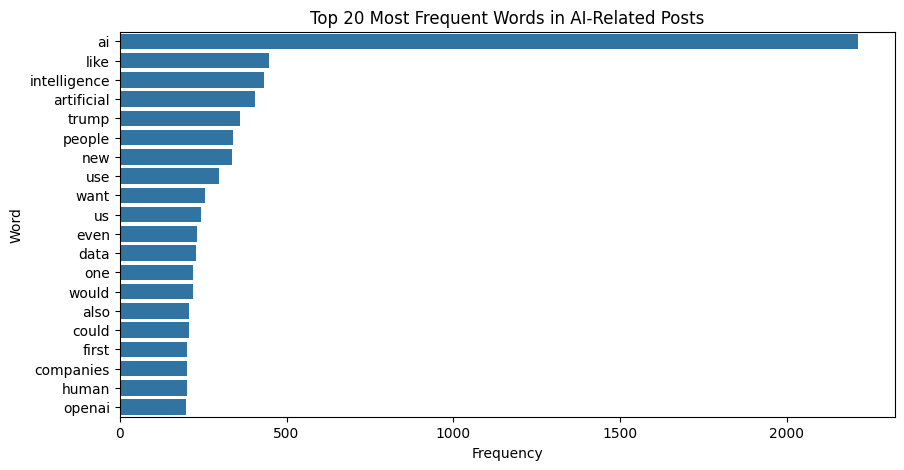

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

words, counts = zip(*top_words)
plt.figure(figsize=(10,5))
sns.barplot(x=list(counts), y=list(words))
plt.title("Top 20 Most Frequent Words in AI-Related Posts")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.savefig("/Users/sagnikchakravarty/Desktop/AI Project/AI_Project/AI_Project/Data Collection/Internet/Images/Unigram.png", 
            dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
stop_words = stopwords.words('english')
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|\.com', '', text)  # remove URLs and .com
    text = re.sub(r'[^a-z\s]', '', text)  # keep only letters and spaces
    return text
df["text"] = df["text"].apply(clean_text)
vectorizer = CountVectorizer(ngram_range = (2,3),
                             stop_words = stop_words,
                             min_df = 2
                             )


X = vectorizer.fit_transform(df["text"])
counts = X.sum(axis=0).A1
phrases = vectorizer.get_feature_names_out()

phrase_counts = list(zip(phrases, counts))
phrase_counts = sorted(phrase_counts, key=lambda x: x[1], reverse=True)

print("Top 20 multi-word topics:")
for phrase, count in phrase_counts[:20]:
    print(f"{phrase}: {count}")

Top 20 multi-word topics:
artificial intelligence: 350
generative ai: 56
machine learning: 52
using ai: 50
use ai: 49
ai models: 44
ai agents: 40
donald trump: 39
sam altman: 35
business creator: 32
elon musk: 32
general intelligence: 32
data science: 31
ai tools: 30
artificial general: 30
artificial general intelligence: 30
ai companies: 26
social media: 26
white house: 26
dont want: 23


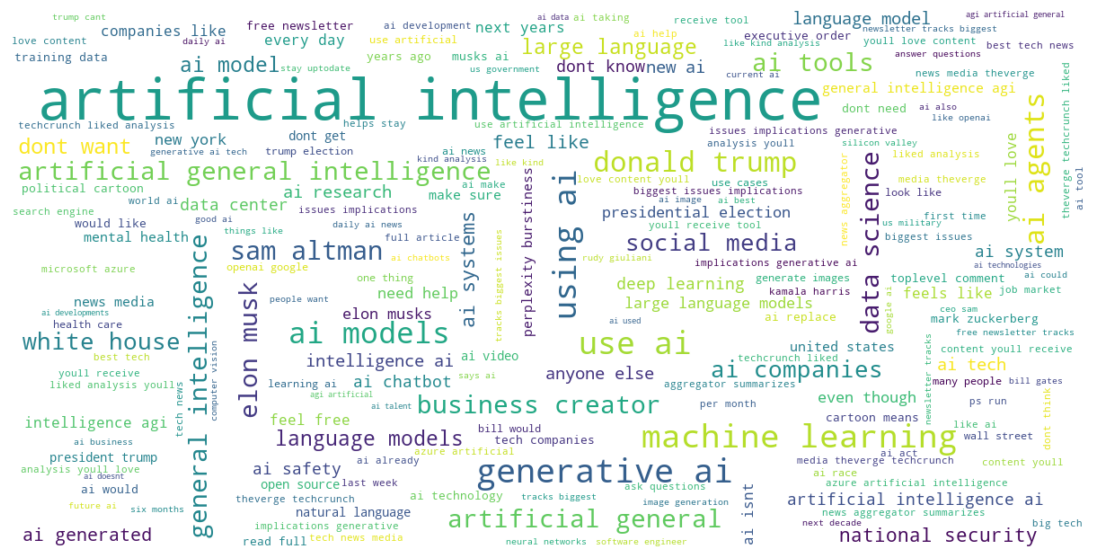

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# Extract bigrams
vectorizer = CountVectorizer(
    ngram_range=(2,3),
    stop_words=stop_words,
    min_df=2
)
X = vectorizer.fit_transform(df["text"])
counts = X.sum(axis=0).A1
phrases = vectorizer.get_feature_names_out()

# Create frequency dictionary for word cloud
freq_dict = dict(zip(phrases, counts))

# Generate word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate_from_frequencies(freq_dict)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig("/Users/sagnikchakravarty/Desktop/AI Project/AI_Project/AI_Project/Data Collection/Internet/Images/BigramTrigramWordCloud.png", 
            dpi=300, bbox_inches='tight')
plt.show()


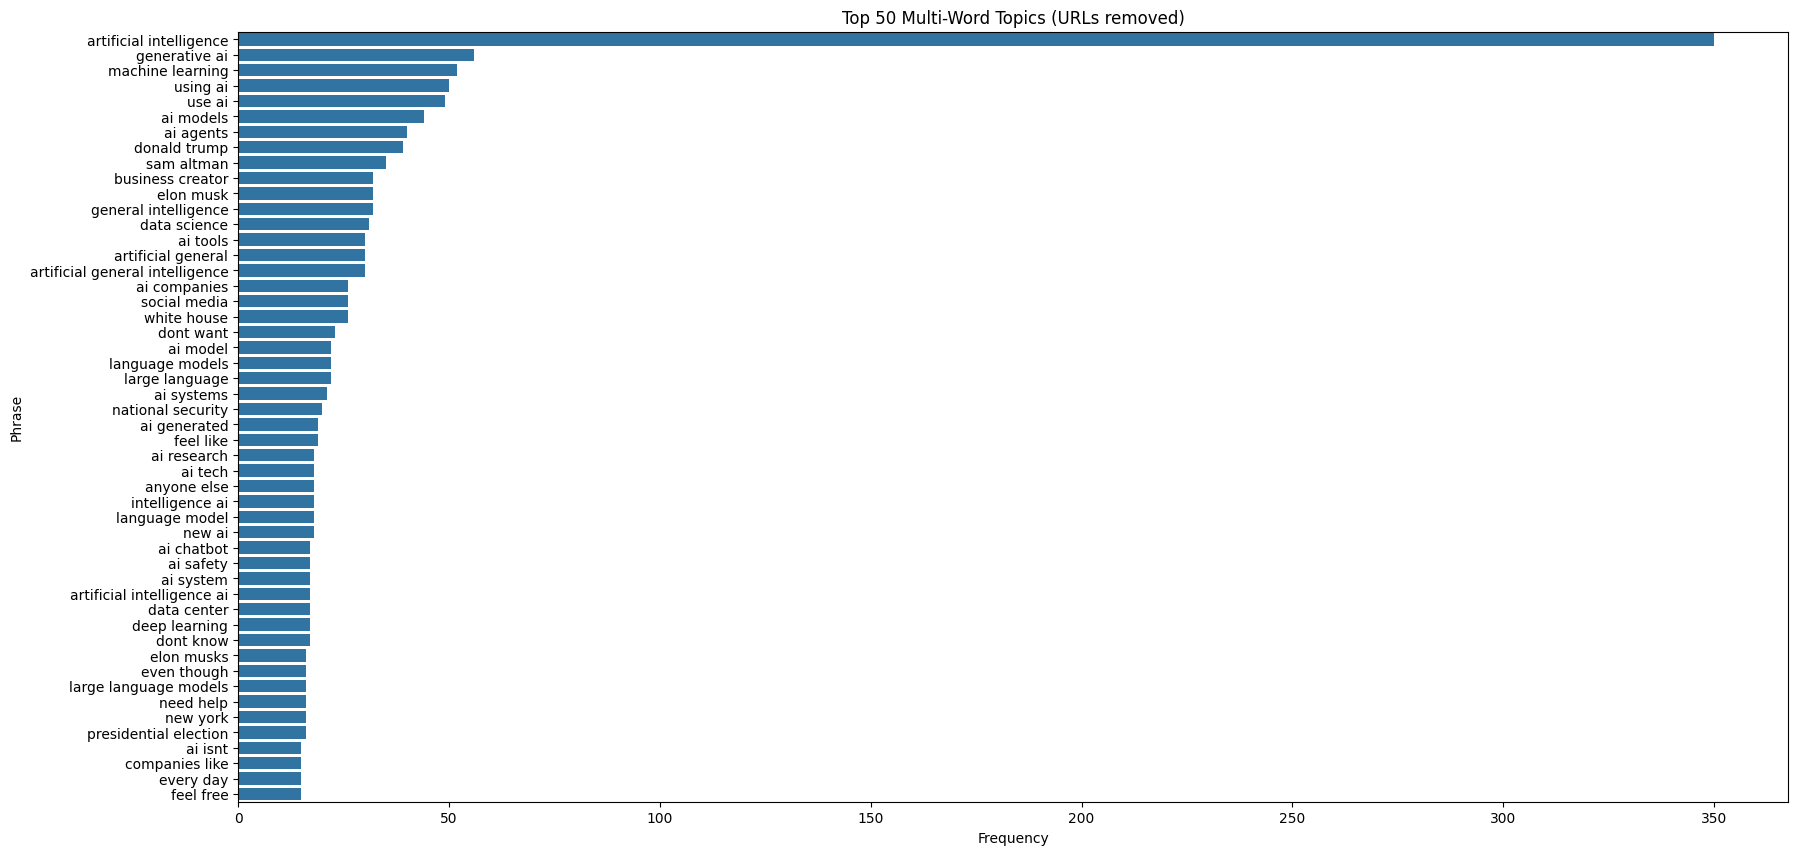

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_phrases, top_counts = zip(*phrase_counts[:50])
plt.figure(figsize=(20,10))
sns.barplot(x=list(top_counts), y=list(top_phrases))
plt.title("Top 50 Multi-Word Topics (URLs removed)")
plt.xlabel("Frequency")
plt.ylabel("Phrase")
plt.savefig("/Users/sagnikchakravarty/Desktop/AI Project/AI_Project/AI_Project/Data Collection/Internet/Images/BigramTrigramHist.png", 
            dpi=300, bbox_inches='tight')
plt.show()


# Getting the data from the list of subreddit we have specified and the keywords we have specified

In [88]:
subreddits = [
    "politics",
    "artificial",
    "artificialinteligence",
    "defendingAIart",
    "cogsci",
    "technology",
    "generativeAI",
    "transhumanism",
    "uncannyvalley",
    "antiAI",
    "automation",
    "agi",
    "aiArt",
    "chatgpt",
    "translation",
    "AskHistorians",
    "news",
    "geopolitics",
    "screenwriting",
    "writing",
    "TalesFromYourServer",
    "nursing",
    "HomeImprovement"
]

keywords = [
    "AI",
    "Deep Fake",
    "Artificial Intelligence",
    "Chat GPT",
    "Open AI",
    "LLAMA",
    "Claude",
    "Anthropic",
    "Sora",
    "Sam Altman",
    "Presidential Election",
    "language model",
    "Machine Learning"
]

In [89]:
def fetch_posts(subreddit_name, query, limit=None, delay=0.5, sort="new"):
    subreddit = reddit.subreddit(subreddit_name)
    posts = []

    print(f"Fetching posts for query: '{query}'")
    for submission in subreddit.search(query, sort=sort, limit=limit):
        posts.append({
            "query": query,
            "title": submission.title,
            "score": submission.score,
            "ups": submission.ups,
            "id": submission.id,
            "url": submission.url,
            "num_comments": submission.num_comments,
            "created_utc": submission.created_utc,
            "author": str(submission.author),
            "selftext": submission.selftext,
            "subreddit": str(submission.subreddit),
            "Keyword": query
        })
        time.sleep(delay)
    return posts

In [92]:
sort = ["relevance", "hot", "top", "new", "comments"]
for s in sort:
    for sub in subreddits:
        for q in keywords:
            print(f"Fetching posts from subreddit '{sub}' for query '{q}' sorted by '{s}'...")
            posts = fetch_posts(sub, q, limit=3000, sort = s, delay=0.25)
            print(f"Fetched {len(posts)} posts.")
            all_posts.extend(posts)

Fetching posts from subreddit 'politics' for query 'AI' sorted by 'relevance'...
Fetching posts for query: 'AI'
Fetched 239 posts.
Fetching posts from subreddit 'politics' for query 'Deep Fake' sorted by 'relevance'...
Fetching posts for query: 'Deep Fake'
Fetched 149 posts.
Fetching posts from subreddit 'politics' for query 'Artificial Intelligence' sorted by 'relevance'...
Fetching posts for query: 'Artificial Intelligence'
Fetched 135 posts.
Fetching posts from subreddit 'politics' for query 'Chat GPT' sorted by 'relevance'...
Fetching posts for query: 'Chat GPT'
Fetched 56 posts.
Fetching posts from subreddit 'politics' for query 'Open AI' sorted by 'relevance'...
Fetching posts for query: 'Open AI'
Fetched 65 posts.
Fetching posts from subreddit 'politics' for query 'LLAMA' sorted by 'relevance'...
Fetching posts for query: 'LLAMA'
Fetched 47 posts.
Fetching posts from subreddit 'politics' for query 'Claude' sorted by 'relevance'...
Fetching posts for query: 'Claude'
Fetched 51 po

In [146]:
# Save to a single CSV
if all_posts:
    df = pd.DataFrame(all_posts)
    print(f"DataFrame has {len(df)} rows before removing duplicates.")
    
    # Drop duplicates by Reddit post ID
    df = df.drop_duplicates(subset=["id"])
    
    print(f"DataFrame now has {len(df)} unique posts after removing duplicates.")
    df.to_csv("reddit_posts.csv", index=False)
    print(f"All posts saved to 'reddit_posts.csv'. Total unique posts: {len(df)}")
else:
    print("No posts found.")


DataFrame has 119198 rows before removing duplicates.
DataFrame now has 36661 unique posts after removing duplicates.
All posts saved to 'reddit_posts.csv'. Total unique posts: 36661


# We will get the Reddit Comments from the post url using praw

In [132]:
def fetch_comments_by_id(post_id):
    submission = reddit.submission(id=post_id)
    submission.comments.replace_more(limit=None)

    comments_data = []
    for comment in submission.comments.list():
        comments_data.append({
            "post_id": submission.id,
            "post_title": submission.title,
            "comment_id": comment.id,
            "comment_body": comment.body,
            "comment_author": str(comment.author),
            "comment_score": comment.score,
            "created_utc": comment.created_utc,
            "subreddit": str(submission.subreddit)
        })
    return comments_data

In [139]:
from tqdm import tqdm

all_comments = []

# Loop over post IDs with a progress bar
for post_id in tqdm(df['id'], desc="Fetching comments"):
    try:
        comments = fetch_comments_by_id(post_id)
        all_comments.extend(comments)
        time.sleep(5)
    except Exception as e:
        print(f"Error fetching comments for post {post_id}: {e}")


Fetching comments:   0%|          | 2/36661 [00:01<5:32:14,  1.84it/s] 

Error fetching comments for post 1nspmlq: received 403 HTTP response
Error fetching comments for post 1n4u384: received 403 HTTP response


Fetching comments:   0%|          | 4/36661 [00:01<2:57:28,  3.44it/s]

Error fetching comments for post 1m578qn: received 403 HTTP response
Error fetching comments for post 1jqqsjy: received 403 HTTP response


Fetching comments:   0%|          | 6/36661 [00:01<2:13:09,  4.59it/s]

...

Fetching comments:   0%|          | 24/36661 [00:04<1:29:40,  6.81it/s]

Error fetching comments for post 1lztm6c: received 403 HTTP response
Error fetching comments for post 1ntn7xv: received 403 HTTP response


Fetching comments:   0%|          | 26/36661 [00:05<1:58:18,  5.16it/s]

Error fetching comments for post 1iesp6w: received 403 HTTP response
Error fetching comments for post 1e955tb: received 403 HTTP response


KeyboardInterrupt: 

In [ ]:
# Convert all comments to a single DataFrame
comments_df = pd.DataFrame(all_comments)
print(f"Total comments collected: {len(comments_df)}")

# Save to CSV
comments_df.to_csv("reddit_comments.csv", index=False)

In [142]:
print("Read-only:", reddit.read_only)         # should be True
sub = reddit.submission(id="1nuvtkz:")
sub.comments.replace_more(limit=0)
for c in sub.comments.list()[:10]:
    print(c.body[:200])

Read-only: False


Forbidden: received 403 HTTP response

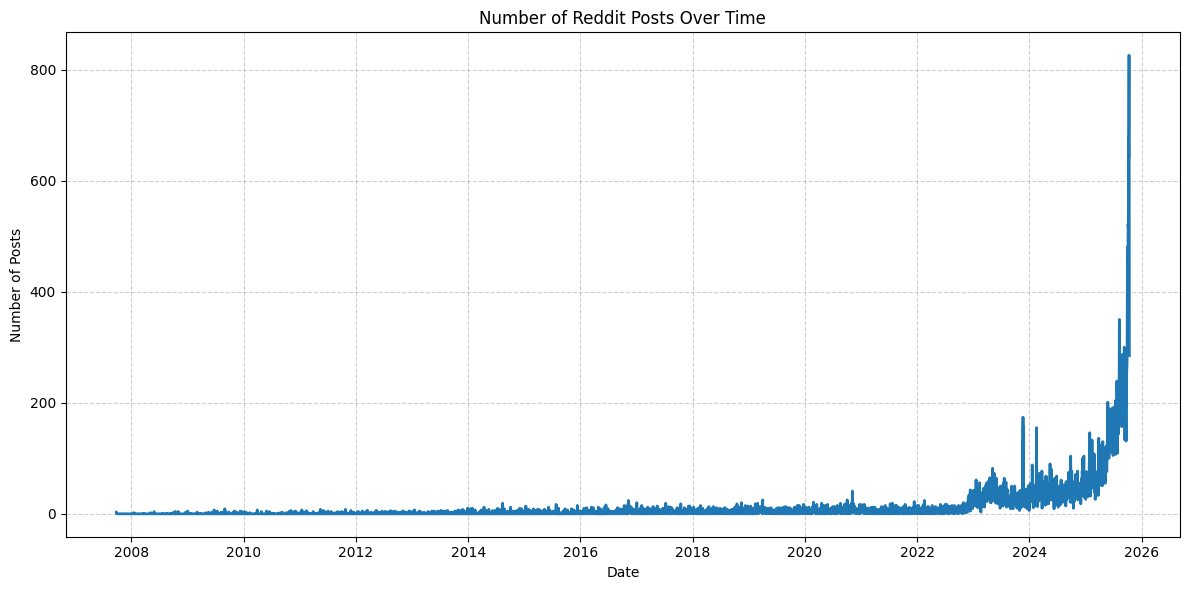

In [145]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("/Users/sagnikchakravarty/Desktop/AI Project/AI_Project/AI_Project/Data Collection/Internet/Data/Reddit/reddit_posts.csv")

# Ensure your timestamp column exists and is in UTC seconds
if 'created_utc' not in df.columns:
    raise ValueError("Column 'created_utc' not found in dataset")

# Convert timestamp to datetime
df['created_dt'] = pd.to_datetime(df['created_utc'], unit='s')

# Set datetime as index
df = df.set_index('created_dt')

# Resample to daily counts
daily_posts = df.resample('D').size()

# Plot
plt.figure(figsize=(12,6))
plt.plot(daily_posts.index, daily_posts.values, linewidth=2)
plt.title("Number of Reddit Posts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Posts")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
